In [1]:
import os
import datetime
# from netCDF4 import Dataset
import numpy as np
import pandas as pd
import xarray as xr
from scipy import signal, integrate, stats
import yaml
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib
from matplotlib.colors import BoundaryNorm, LogNorm
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d import Axes3D, axes3d

import cmaps, plt_helper, filter

plt.style.use('latex_default.mplstyle')

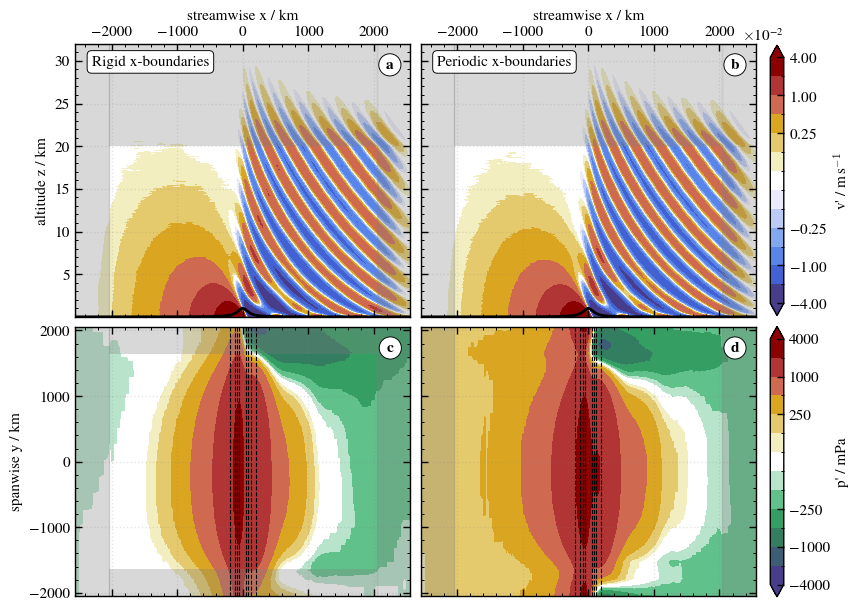

In [3]:
model = "pmap"
folder = "/work/bd0620/b309199/linear-mws"
# sims = [f"pmap_mpdata_MW_100km", f"pmap_bcy1_MW_100km"]
# sims = [f"pmap_mpdata_MW_100km", f"pmap_bcx1_MW_100km"]
sims = [f"pmap_mpdata_MW_100km", f"pmap_mpdata_relay1_MW_100km"]
# sims = [f"pmap_bcx0_ld_MW_100km", f"pmap_bcx1_ld_MW_100km"]

labels = ["Rigid x-boundaries", "Periodic x-boundaries"]

var0 = "v"
# clev, clev_l = plt_helper.get_colormap_bins_and_labels(max_level=0.8)
clev   = [-4,-2,-1,-0.5,-0.25,-0.125,-0.0625,0.0625,0.125,0.25,0.5,1,2,4]
clev_l = [-4,-1,-0.25,0.25,1,4]
clev = np.array(clev) / 100
clev_l = np.array(clev_l) / 100
cbar_label0 = r"v' / m$\,$s$^{-1}$"
cmap = cmaps.get_wave_cmap()
norm = BoundaryNorm(boundaries=clev , ncolors=cmap.N, clip=True)

var1 = "pprime"
# clev1, clev_l1 = plt_helper.get_colormap_bins_and_labels(max_level=2)
clev1 = [-4,-2,-1,-0.5,-0.25,-0.125,-0.0625,-0.03125,0.03125,0.0625,0.125,0.25,0.5,1,2,4]
clev1 = [-4,-2,-1,-0.5,-0.25,-0.125,-0.0625,0.0625,0.125,0.25,0.5,1,2,4]
clev_l1 = [-4,-1,-0.25,0.25,1,4]
clev1 = np.array(clev1) * 1000
clev_l1 = np.array(clev_l1) * 1000
# clev1 = np.linspace(-1,1.1,20)
# clev_l1 = np.linspace(-1,1.1,10)
cbar_label1 = r"p' / mPa"
# cmap1 = cmaps.get_wave_cmap()
cmap1 = plt.get_cmap('RdBu_r')
cmap1 = plt.get_cmap('PiYG_r')
cmap1 = plt.get_cmap('PRGn_r')
cmap1 = cmaps.get_purplegold_cmap()
cmap1 = cmaps.get_bluegreen_cmap()
# cmap1 = cmaps.get_spectral_white_cmap()
# cmap1 = cmaps.get_coolwarm_soft_cmap()
norm1 = BoundaryNorm(boundaries=clev1, ncolors=cmap1.N, clip=True)

gskw  = {'hspace':0.03, 'wspace':0.04, 'height_ratios': [5,5], 'width_ratios': [8,8,2]} #  , 'width_ratios': [5,5]}
fig, axes = plt.subplots(2,3, figsize=(10,7.2), gridspec_kw=gskw)

z=0
t = -1

axes[0,2].axis('off')
axes[1,2].axis('off')

for i, sim in enumerate(sims):
    fpath = os.path.join(folder,sim)
    if model == "pmap":
        dsxz, dsxy, cfg = plt_helper.preprocess_pmap(fpath, t=t, slices={"x": 0, "y": 0, "z": 0})
        dsxz['xcr']=dsxz.x.expand_dims(ycr=np.shape(dsxy['w'])[0]) / 1000
        dsxz['zcr']=dsxz.zcr / 1000
        dsxy['xcr']=dsxy.x.expand_dims(y=np.shape(dsxy['w'])[0])  / 1000
        dsxy['ycr']=dsxy.y.expand_dims(x=np.shape(dsxy['w'])[1], axis=1)  / 1000
        dsxy['zcr']=dsxy['zcr'] / 1000
    else:
        _, dsxz, _, ds_xyslices = plt_helper.preprocess_eulag_tstep(fpath, t, slices={"x": 0, "y": 0, "z": [0]})
        dsxy = ds_xyslices[0]
        dsxy['zcr']=dsxy['zcrtopo'] / 1000
        cfg = None

    ax0 = axes[0,i]
    ax1 = axes[1,i]
    ax1.set_aspect('equal')

    var0_filtered = dsxz[var0].values
    # var0_filtered = filter.fil2dx(var0_filtered,  ifil=50)
    contf = ax0.contourf(dsxz.xcr[0,:].expand_dims(z=np.shape(dsxz['w'])[0]),
                            dsxz.zcr, var0_filtered, cmap=cmap, norm=norm, levels=clev, extend='both')
    ax0.plot(dsxz.x/1000,100*dsxz.zcr[0,:],lw=2,color='black')
    # ax0.text(0.03, 0.94, 'a', transform=ax0.transAxes, weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})

    ax0.xaxis.set_label_position('top')
    ax0.set_xlabel("streamwise x / km")
    ax0.tick_params(which='both',labeltop=True, labelbottom=False, labelleft=False)

    var1_filtered = 1000 * filter.fil2dx(dsxy[var1].values, ifil=1)
    # var1_filtered = 1000 * filter.fil2dx(dsxy[var1].values, ifil=10)
    contf1 = ax1.contourf(dsxy.xcr, dsxy.ycr, var1_filtered, cmap=cmap1, norm=norm1, levels=clev1, extend='both')
    ax1.contour(dsxy.xcr, dsxy.ycr, 100*dsxy["zcr"], colors='k',
                linestyles='dashed', levels=[0.2,0.4,0.6,0.8,1])
    
    ax1.tick_params(which='both',labelbottom=False)
    ax0.text(0.05, 0.92, labels[i], transform=ax0.transAxes, bbox={"boxstyle" : "round", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
    if i == 0:
        ax0.tick_params(which='both', labelleft=True)
        ax0.set_ylabel("altitude z / km")
        ax1.set_ylabel("spanwise y / km")
    else:
        ax1.tick_params(which='both', labelleft=False)
        # [label.set_horizontalalignment('left') for label in ax1.get_yticklabels()]
        # ax1.tick_params(axis="y", pad=-7)
        # ax1.set_yticks([-1000,0,1000])
        
    ## Sponge layer
    alpha_sponge = 0.3
    csponge = "grey"
    
    xsponge = [(dsxz.x[0] + cfg['absorber']['widthx'])/1000, (dsxz.x[-1] - cfg['absorber']['widthx'])/1000]
    zsponge = [(dsxz.zcr.max().values - cfg['absorber']['depth']/1000), dsxz.zcr.max().values]
    ax0.fill_between(xsponge, [zsponge[1],zsponge[1]], [zsponge[0],zsponge[0]], facecolor=csponge, alpha=alpha_sponge)
    ax0.axvspan(dsxz.x[0]/1000, (dsxz.x[0]+cfg['absorber']['widthx'])/1000, alpha=alpha_sponge, color=csponge)
    ax0.axvspan((dsxz.x[-1] - cfg['absorber']['widthx'])/1000, dsxz.x[-1]/1000, alpha=alpha_sponge, color=csponge)
    
    ax1.axvspan(dsxy.x[0]/1000, (dsxy.x[0]+cfg['absorber']['widthx'])/1000, alpha=alpha_sponge, color=csponge)
    ax1.axvspan((dsxy.x[-1] - cfg['absorber']['widthx'])/1000, dsxy.x[-1]/1000, alpha=alpha_sponge, color=csponge)
    if i in [0]:
        ax1.fill_between(xsponge, [(dsxy.y[0]+cfg['absorber']['widthy'])/1000, (dsxy.y[0]+cfg['absorber']['widthy'])/1000], [dsxy.y[0]/1000,dsxy.y[0]/1000], facecolor=csponge, alpha=alpha_sponge)
        ax1.fill_between(xsponge, [dsxy.y[-1]/1000, dsxy.y[-1]/1000], [(dsxy.y[-1]-cfg['absorber']['widthy'])/1000, (dsxy.y[-1]-cfg['absorber']['widthy'])/1000], facecolor=csponge, alpha=alpha_sponge)

numstr = ['a','b','c','c','d','d']
for i, ax in enumerate(axes.flatten()):
    if i in [0,1,3,4]:
        ax.text(0.95, 0.91, numstr[i], transform=ax.transAxes, horizontalalignment='right', weight='bold', bbox={"boxstyle" : "circle", "lw":0.67, "facecolor":"white", "edgecolor":"black"})
        ax.grid()
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

cbar = fig.colorbar(
    contf, ax=axes[0,2], location='right',
    fraction=0.95, shrink=0.99, ticks=clev_l, label=cbar_label0, pad=0, extend='both')

cbar.formatter.set_powerlimits((0, 0))
cbar.formatter.set_useMathText(True)

fig.colorbar(
    contf1, ax=axes[1,2], location='right',
    fraction=0.95, shrink=0.99, ticks=clev_l1, label=cbar_label1, pad=0, extend='both')

fig_title = 'slices_bcx_comp.png'
fig.savefig(os.path.join('../data/pmap', fig_title), facecolor='w', edgecolor='w',
                format='png', dpi=300, bbox_inches='tight')